# IMPORT

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from collections import deque
import random
import math
from skimage import data

## Bài 1 - Cài đặt Canny từ Đầu

### 1.1 Pipeline Canny - Bốn bước

#### Bước 1 - Gaussian Smoothing

- Mục đích: Làm mờ ảnh trước khi tính toán gradient nhằm lọc bỏ các nhiễu nhỏ có thể gây ra các cạnh giả.  
- Lựa chọn tham số $\sigma$: * $\sigma$ nhỏ: Giữ được nhiều chi tiết nhưng dễ bị nhạy cảm với nhiễu.  
$\sigma$ lớn: Lọc nhiễu tốt hơn nhưng làm mờ các chi tiết nhỏ.  
Điểm khởi đầu thực tế: Thường chọn $\sigma = 1.0$ đến $2.0$.

### Bước 2 - Gradient M và θ
Áp dụng Sobel lên ảnh đã blur để ra Gx, Gy, tính M và θ. Thứ tự quan trọng:
blur trước, Sobel sau.

### Bước 3 - Non-maximum Suppression (NMS)
Thuật toán cho mỗi pixel p:
1. Lượng hoá θ(p) về 1 trong 4 hướng: 0°, 45°, 90°, 135° (mỗi vùng rộng 45°,
xử lý wrap-around trên [0°, 180°)).
2. Xác định hai hàng xóm q1, q2 dọc theo hướng đó.
3. Nếu M(p) < M(q1) hoặc M(p) < M(q2): xoá p (gán 0).
4. Ngược lại: giữ p.

### Bước 4 - Hysteresis Thresholding
Dùng hai ngưỡng τlow < τhigh:
- M(p) ≥ τhigh: strong edge – giữ chắc chắn.
- τlow ≤ M(p) < τhigh: weak edge – giữ nếu kết nối với strong.
- M(p) < τlow: nhiễu – loại bỏ.
Edge tracking: từ mỗi strong edge, duyệt 8-kết nối (DFS/BFS) để tìm tất
cả weak edge có thể đến được. Weak edge không kết nối với bất kỳ strong
edge nào bị loại bỏ.

In [2]:
def convolve2d(image, kernel):
    """
    Hàm thực hiện tích chập (convolution) 2D giữa ảnh và một kernel.
    Hỗ trợ xử lý viền bằng cách padding sao chép (edge padding).
    """
    kernel = np.atleast_2d(kernel)
    # Lật kernel theo cả hai chiều đối với phép tích chập chuẩn
    kernel = np.flipud(np.fliplr(kernel))
    
    ih, iw = image.shape
    kh, kw = kernel.shape
    
    # Tính toán kích thước padding
    pad_h = kh // 2
    pad_w = kw // 2
    
    # Thực hiện padding cho ảnh (dùng mode 'edge' để tránh viền đen giả)
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    
    # Khởi tạo ảnh kết quả
    output = np.zeros_like(image, dtype=np.float64)
    
    # Thực hiện trượt kernel và tính tích chập
    for i in range(ih):
        for j in range(iw):
            region = padded_img[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
            
    return output

def gaussian_kernel(size, sigma=1.0):
    """
    Khởi tạo ma trận bộ lọc Gaussian 2D[cite: 313, 325].
    """
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0 * sigma**2))) * normal
    return g / np.sum(g) # Chuẩn hóa để tổng trọng số bằng 1

def canny_edge_detection(gray_img, sigma=1.0, kernel_size=5, tau_low=None, tau_high=None):
    """
    Cài đặt toàn bộ Pipeline Canny qua 4 bước[cite: 322, 324]:
    1. Gaussian Blur [cite: 324, 325]
    2. Sobel Gradients (M, theta) [cite: 324, 328]
    3. Non-maximum Suppression (NMS) [cite: 324, 347]
    4. Hysteresis Thresholding (Dùng DFS/BFS) [cite: 324, 360, 378]
    """
    # Đảm bảo ảnh đầu vào là grayscale và float64 [cite: 321]
    img = gray_img.astype(np.float64)

    g_kernel = gaussian_kernel(kernel_size, sigma)
    blurred_img = convolve2d(img, g_kernel)
    
    # Định nghĩa ma trận Sobel theo tài liệu [cite: 314, 315]
    K_x = np.array([[-1, 0, 1], 
                    [-2, 0, 2], 
                    [-1, 0, 1]], dtype=np.float64)
    
    K_y = np.array([[-1, -2, -1], 
                    [ 0,  0,  0], 
                    [ 1,  2,  1]], dtype=np.float64)
    
    # Áp dụng bộ lọc Sobel [cite: 329]
    G_x = convolve2d(blurred_img, K_x)
    G_y = convolve2d(blurred_img, K_y)
    
    # Tính Magnitude M và Hướng theta (radian) [cite: 307]
    M = np.sqrt(G_x**2 + G_y**2)
    theta = np.arctan2(G_y, G_x) # Trả về góc trong khoảng [-pi, pi]
    
    # Chuyển đổi theta sang độ và chuẩn hóa về đoạn [0, 180) [cite: 350]
    theta_deg = np.rad2deg(theta)
    theta_deg[theta_deg < 0] += 180
    
    H, W = M.shape
    NMS_output = np.zeros((H, W), dtype=np.float64)
    
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            angle = theta_deg[i, j]
            
            # Lượng hoá góc về 4 hướng: 0, 45, 90, 135 [cite: 350]
            # Hướng 0 độ (Cạnh chạy dọc -> Kiểm tra hàng xóm trái/phải) [cite: 311, 350]
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                q1 = M[i, j + 1]
                q2 = M[i, j - 1]
            # Hướng 45 độ (Đường chéo phải -> Kiểm tra chéo trên-phải / dưới-trái) [cite: 350]
            elif (22.5 <= angle < 67.5):
                q1 = M[i - 1, j + 1]
                q2 = M[i + 1, j - 1]
            # Hướng 90 độ (Cạnh chạy ngang -> Kiểm tra hàng xóm trên/dưới) [cite: 350]
            elif (67.5 <= angle < 112.5):
                q1 = M[i - 1, j]
                q2 = M[i + 1, j]
            # Hướng 135 độ (Đường chéo trái -> Kiểm tra chéo trên-trái / dưới-phải) [cite: 350]
            elif (112.5 <= angle < 157.5):
                q1 = M[i - 1, j - 1]
                q2 = M[i + 1, j + 1]
                
            # Giữ lại nếu là cực đại cục bộ, ngược lại gán bằng 0 [cite: 348, 352, 353]
            if (M[i, j] >= q1) and (M[i, j] >= q2):
                NMS_output[i, j] = M[i, j]
            else:
                NMS_output[i, j] = 0
                
    # Nếu không truyền ngưỡng, thiết lập mặc định thực tế
    if tau_high is None:
        tau_high = float(np.max(NMS_output) * 0.2)
        
    if tau_low is None:
        tau_low = float(tau_high * 0.5)
        
    final_output = np.zeros((H, W), dtype=np.uint8)
    
    # Phân loại ban đầu: 2 ứng với Strong, 1 ứng với Weak, 0 là loại bỏ 
    strong_i, strong_j = np.where(NMS_output >= tau_high)
    weak_i, weak_j = np.where((NMS_output >= tau_low) & (NMS_output < tau_high))
    
    # Bản đồ trạng thái cạnh để phục vụ lan truyền đồ thị
    # 255: Strong Edge, 50: Weak Edge, 0: Loại bỏ
    final_output[strong_i, strong_j] = 255
    final_output[weak_i, weak_j] = 50
    
    # Sử dụng cấu trúc ngăn xếp (Stack) thuật toán DFS để duyệt và lan truyền đúng thứ tự 
    # Đẩy tất cả các pixel Strong Edge vào stack làm điểm khởi hành 
    stack = list(zip(strong_i, strong_j))
    
    # Các bước di chuyển xung quanh 8-kết nối
    directions = [(-1, -1), (-1, 0), (-1, 1), 
                  (0, -1),           (0, 1), 
                  (1, -1),  (1, 0),  (1, 1)]
    
    while len(stack) > 0:
        curr_i, curr_j = stack.pop()
        
        # Duyệt qua các hàng xóm 8-kết nối xung quanh
        for di, dj in directions:
            ni, nj = curr_i + di, curr_j + dj
            
            # Kiểm tra biên ma trận ảnh
            if 0 <= ni < H and 0 <= nj < W:
                if final_output[ni, nj] == 50:
                    final_output[ni, nj] = 255
                    stack.append((ni, nj))
                    
    # Sau khi duyệt DFS xong, loại bỏ hoàn toàn tất cả các weak edge cô lập không được promote
    final_output[final_output == 50] = 0
    
    return final_output


def otsu_threshold_for_gradient(magnitude_image):
    """
    Thuật toán Otsu tự động tìm ngưỡng tối ưu từ histogram của bản đồ gradient M[cite: 381].
    """
    # Làm phẳng ảnh biên độ và chuyển về dạng số nguyên 8-bit [0-255] để lập histogram
    M_normalized = ((magnitude_image / np.max(magnitude_image)) * 255).astype(np.uint8)
    
    # Tính toán Histogram
    hist, bin_edges = np.histogram(M_normalized, bins=256, range=(0, 256))
    
    total_pixels = M_normalized.size
    current_max_variance = 0.0
    otsu_threshold = 0
    
    # Tính tổng tích lũy cường độ phục vụ tính trung bình nhanh
    sum_total = np.sum(np.arange(256) * hist)
    
    weight_background = 0.0
    sum_background = 0.0
    
    for t in range(256):
        weight_background += hist[t]
        if weight_background == 0:
            continue
            
        weight_foreground = total_pixels - weight_background
        if weight_foreground == 0:
            break
            
        sum_background += float(t * hist[t])
        
        # Tính giá trị trung bình cường độ các lớp (mu) [cite: 385]
        mu_background = sum_background / weight_background
        mu_foreground = (sum_total - sum_background) / weight_foreground
        
        # Tỷ lệ pixel w_k của mỗi lớp [cite: 385]
        w_b = weight_background / total_pixels
        w_f = weight_foreground / total_pixels
        
        # Công thức tính Phương sai liên lớp (Between-class variance) [cite: 382]
        var_between = w_b * w_f * (mu_background - mu_foreground) ** 2
        
        # Cập nhật ngưỡng tối đa hóa phương sai [cite: 382, 383]
        if var_between > current_max_variance:
            current_max_variance = var_between
            otsu_threshold = t
            
    # Chuyển giá trị ngưỡng từ thang [0-255] ngược lại thang giá trị thực tế của ma trận M
    actual_tau_high = (otsu_threshold / 255.0) * np.max(magnitude_image)
    return actual_tau_high

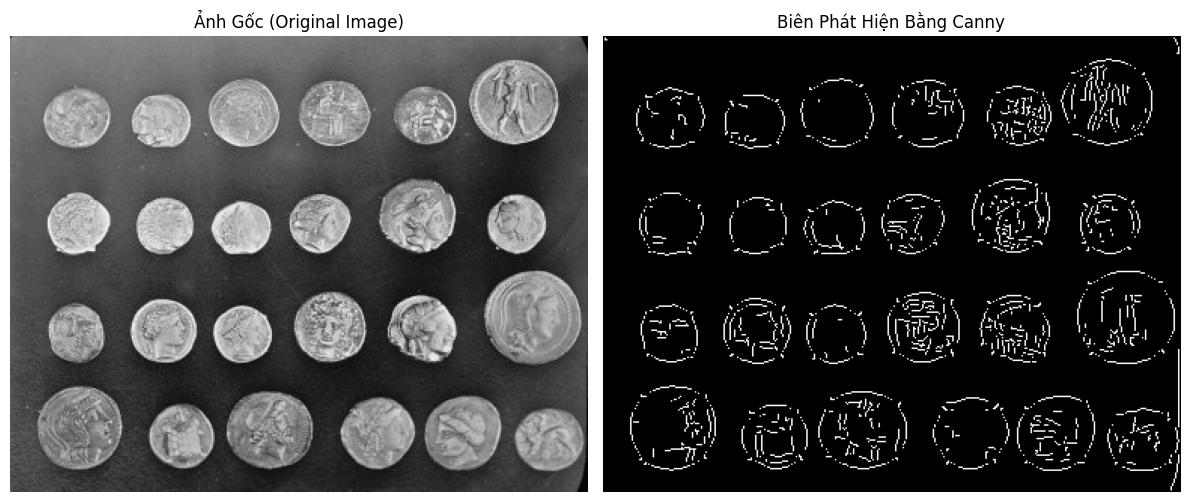

In [3]:
# 1. Tải ảnh xám thực tế mẫu từ thư viện (Ảnh đồng xu rất phù hợp cho bài toán tìm biên)
image = data.coins() 

# 2. Chạy hàm Canny tự viết từ đầu (From Scratch) bằng NumPy
# Điểm khởi đầu thực tế: sigma từ 1.0 đến 2.0 theo tài liệu hướng dẫn
edges_custom = canny_edge_detection(image, sigma=1.4, kernel_size=5, tau_low=30, tau_high=80)

# 3. Hiển thị kết quả so sánh trực quan
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Ảnh Gốc (Original Image)')
ax[0].axis('off')

ax[1].imshow(edges_custom, cmap='gray')
ax[1].set_title('Biên Phát Hiện Bằng Canny')
ax[1].axis('off')

plt.tight_layout()
plt.show()

## 1.3 So sánh implementation với cv2.Canny bằng chỉ số IoU (Inter-section over Union).

Công thức và Ý nghĩa của IoU trong Tìm BiênChỉ số IoU đánh giá độ tương đồng giữa hai tập hợp pixel biên. Đối với ảnh nhị phân (chỉ gồm pixel biên giá trị 255 và pixel nền giá trị 0), công thức được định nghĩa như sau:  $$IoU = \frac{|A \cap B|}{|A \cup B|}$$
Phần giao (Intersection - $A \cap B$): Số lượng vị trí pixel mà cả hai hàm đều nhận diện là biên (cùng có giá trị 255).

Phần hợp (Union - $A \cup B$): Tổng số lượng vị trí pixel được nhận diện là biên bởi ít nhất một trong hai hàm.

 CHỈ SỐ IoU ĐẠT ĐƯỢC: 0.3416 (34.16%)


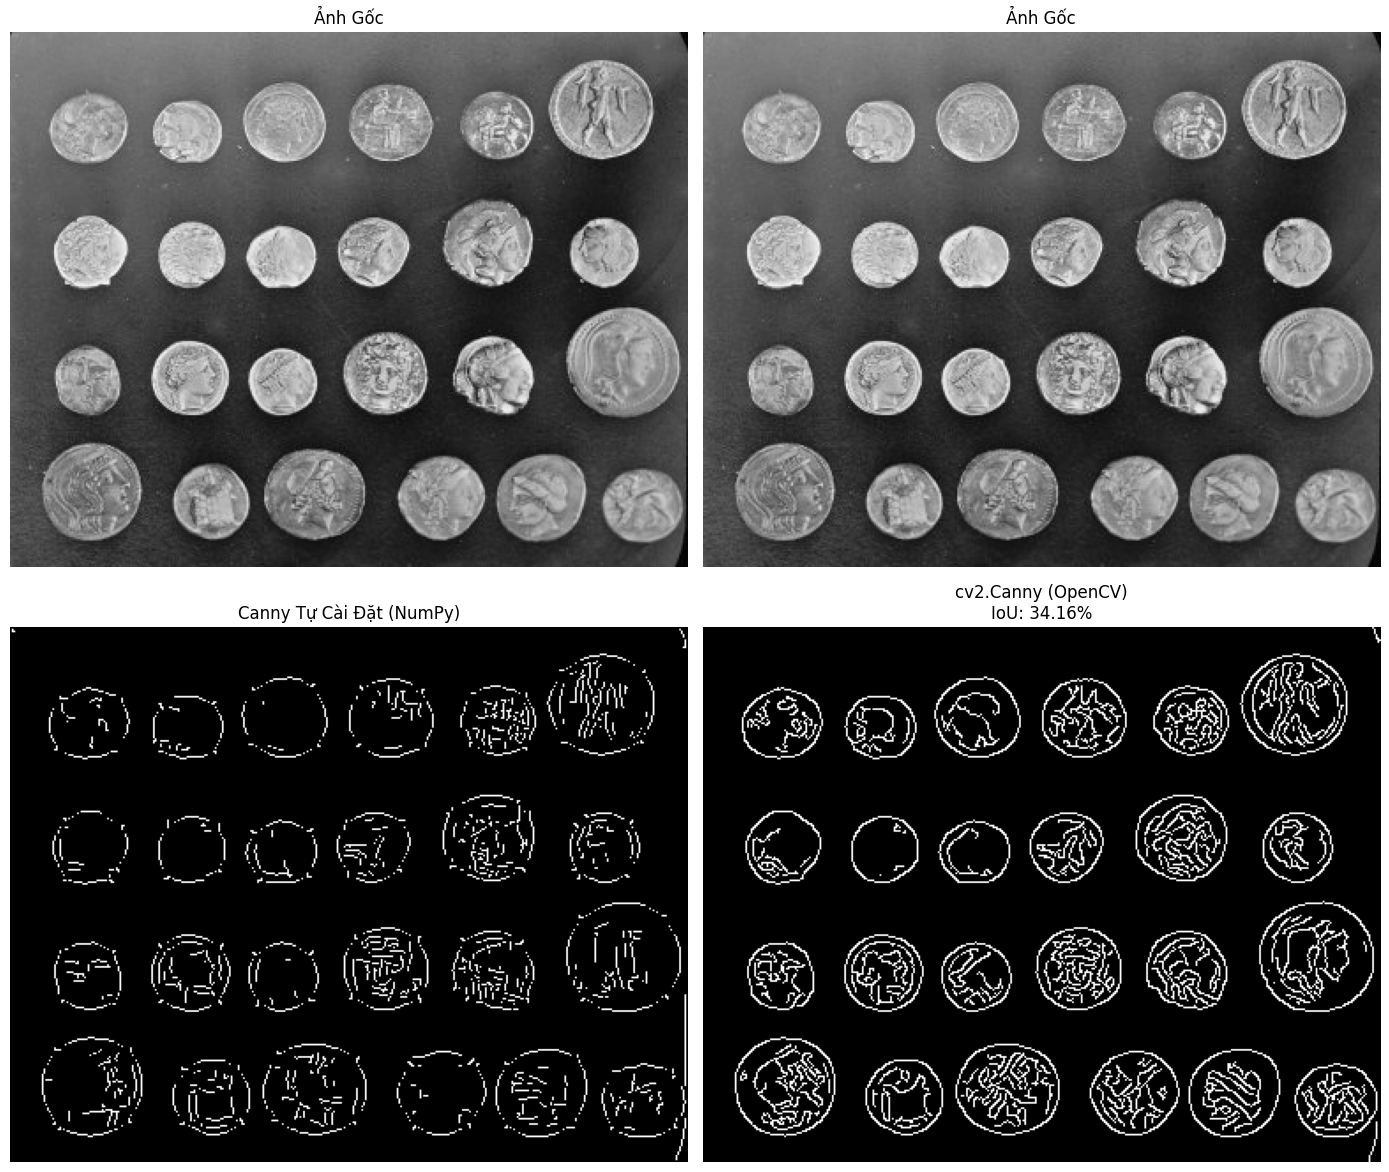

In [4]:
image = data.coins()
sigma = 1.4
kernel_size = 5
tau_low = 30
tau_high = 80

edges_custom = canny_edge_detection(image, sigma=sigma, kernel_size=kernel_size, 
                                     tau_low=tau_low, tau_high=tau_high)

# Bước 1: OpenCV yêu cầu làm mịn bằng GaussianBlur trước một cách tường minh
blurred_opencv = cv2.GaussianBlur(image, (kernel_size, kernel_size), sigmaX=sigma, sigmaY=sigma)
# Bước 2: Gọi hàm Canny của thư viện cv2
edges_opencv = cv2.Canny(blurred_opencv, threshold1=tau_low, threshold2=tau_high)

def calculate_iou(binary_img1, binary_img2):
    """
    Tính chỉ số IoU giữa hai ảnh biên nhị phân (0 và 255).
    """
    # Chuyển đổi thành mảng Boolean (True tại nơi có biên 255)
    border1 = (binary_img1 == 255)
    border2 = (binary_img2 == 255)
    
    # Tính phần giao (Intersection): Cả hai cùng là True
    intersection = np.logical_and(border1, border2).sum()
    
    # Tính phần hợp (Union): Ít nhất một trong hai là True
    union = np.logical_or(border1, border2).sum()
    
    # Tránh lỗi chia cho 0 nếu cả hai ảnh đều không có biên
    if union == 0:
        return 1.0
        
    return intersection / union

# Tính toán IoU thực tế
iou_score = calculate_iou(edges_custom, edges_opencv)

print(f"=========================================")
print(f" CHỈ SỐ IoU ĐẠT ĐƯỢC: {iou_score:.4f} ({iou_score * 100:.2f}%)")
print(f"=========================================")

# Thay đổi cấu hình subplot thành 2 hàng, 2 cột (2, 2)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ---------------- HÀNG 1: ẢNH GỐC ĐỂ ĐỐI CHIẾU ----------------
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Ảnh Gốc')
axes[0, 0].axis('off')

axes[0, 1].imshow(image, cmap='gray')
axes[0, 1].set_title('Ảnh Gốc')
axes[0, 1].axis('off')

# ---------------- HÀNG 2: KẾT QUẢ PHÁT HIỆN BIÊN ----------------
axes[1, 0].imshow(edges_custom, cmap='gray')
axes[1, 0].set_title('Canny Tự Cài Đặt (NumPy)')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_opencv, cmap='gray')
axes[1, 1].set_title(f'cv2.Canny (OpenCV)\nIoU: {iou_score * 100:.2f}%')
axes[1, 1].axis('off')

# Tối ưu khoảng cách giữa các hình ảnh để không bị đè chữ
plt.tight_layout()
plt.show()

## 1.4 Nếu kết quả có quá nhiều cạnh giả, bạn điều chỉnh tham số nào trước tiên và theo hướng nào? Giải thích dựa trên cơ chế thuật toán.

### Tham số cần điều chỉnh đầu tiên: Tăng độ lệch chuẩn $\sigma$ (Sigma) của bộ lọc Gaussian

Giải thích dựa trên cơ chế thuật toán:
- Bản chất của cạnh giả: Nguyên nhân cốt lõi tạo ra cạnh giả là do hiện tượng nhiễu ở cấp độ pixel hoặc các vân bề mặt quá chi tiết (kết cấu dày đặc). Khi tính đạo hàm (sai phân), những sự thay đổi đột ngột do nhiễu này sẽ tạo ra các giá trị gradient cực kỳ lớn, đánh lừa máy tính đó là một cạnh.  
- Cơ chế của Gaussian Blur: Bước đầu tiên trong Canny là làm mịn ảnh bằng bộ lọc Gaussian. Độ lệch chuẩn $\sigma$ chính là tham số quyết định "độ rộng" và "độ mạnh" của việc làm mờ.  
- Tác động khi tăng $\sigma$: Khi tăng $\sigma$, trọng số của bộ lọc Gaussian sẽ trải rộng ra, giúp san phẳng và triệt tiêu các tần số cao (nhiễu liti, hạt nhiễu) một cách hiệu quả trước khi ảnh được đưa vào bộ lọc Sobel. Khi nhiễu đã bị xóa nhòa, ma trận Gradient Magnitude $M$ ở bước 2 sẽ không còn các đỉnh nhọn giả tạo, từ đó loại bỏ tận gốc các cạnh giả ngay từ đầu pipeline

### Tham số cần điều chỉnh TIẾP THEO: Tăng cặp ngưỡng $\tau_{high}$ và $\tau_{low}$ (Hysteresis Thresholding)

Nếu sau khi tăng $\sigma$ mà ảnh vẫn còn cạnh giả, bạn cần can thiệp vào bộ lọc ở bước cuối cùng.
Giải thích dựa trên cơ chế thuật toán:
- Cơ chế lọc của Hysteresis: Bước này sử dụng $\tau_{high}$ để nhặt ra các "cạnh mạnh" chắc chắn giữ lại, và $\tau_{low}$ để giữ các "cạnh yếu" kết nối với cạnh mạnh. Tất cả pixel có độ mạnh gradient nhỏ hơn $\tau_{low}$ sẽ bị coi là nhiễu và loại bỏ hoàn toàn.  
- Tác động khi tăng ngưỡng: * Khi bạn tăng $\tau_{high}$, thuật toán sẽ siết chặt điều kiện để một pixel được công nhận là "cạnh mạnh". Những đoạn nhiễu có gradient hơi cao nhưng chưa đủ độ sắc nét sẽ bị rớt xuống nhóm "cạnh yếu" hoặc bị loại bỏ.  
- Khi bạn tăng $\tau_{low}$, bạn đang nâng cao "bức tường" lọc nhiễu. Các cạnh yếu do nhiễu còn sót lại sau bước blur sẽ bị chặn đứng hoàn toàn và gán bằng 0, không cho phép tham gia vào quá trình dò vết biên (Edge tracking).  

# 2 – Otsu Thresholding cho Canny Edge Detection

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

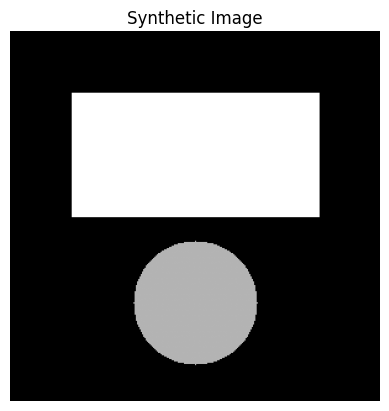

In [6]:
img = np.zeros((300,300), dtype=np.uint8)

cv2.rectangle(img,(50,50),(250,150),255,-1)

cv2.circle(img,(150,220),50,180,-1)

plt.imshow(img,cmap='gray')
plt.title("Synthetic Image")
plt.axis('off')
plt.show()

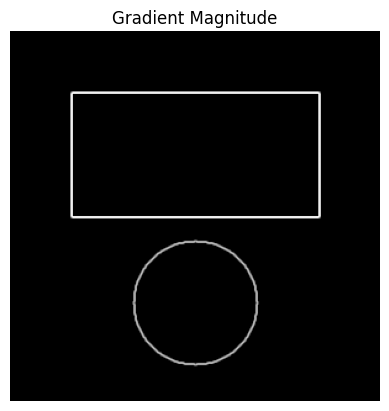

In [7]:
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

M = np.sqrt(gx**2 + gy**2)

M = np.uint8(M / M.max() * 255)

plt.imshow(M, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')
plt.show()

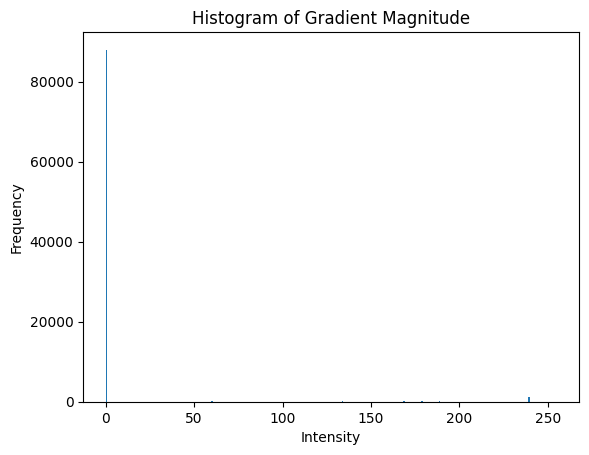

In [8]:
plt.hist(M.ravel(), bins=256)
plt.title("Histogram of Gradient Magnitude")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

In [9]:
tau_high, _ = cv2.threshold(
    M,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

tau_low = 0.5 * tau_high

print("tau_high =", tau_high)
print("tau_low =", tau_low)

tau_high = 85.0
tau_low = 42.5


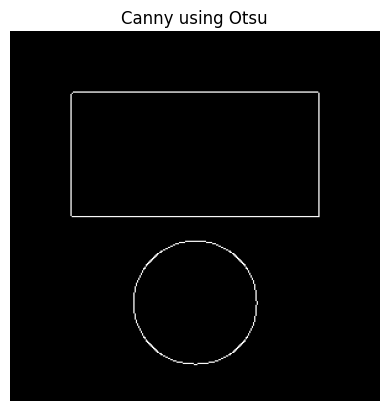

In [10]:
edges_otsu = cv2.Canny(
    img,
    int(tau_low),
    int(tau_high)
)

plt.imshow(edges_otsu, cmap='gray')
plt.title("Canny using Otsu")
plt.axis('off')
plt.show()

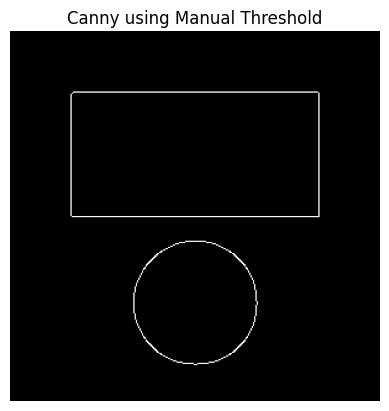

In [11]:
edges_manual = cv2.Canny(
    img,
    50,
    100
)

plt.imshow(edges_manual, cmap='gray')
plt.title("Canny using Manual Threshold")
plt.axis('off')
plt.show()

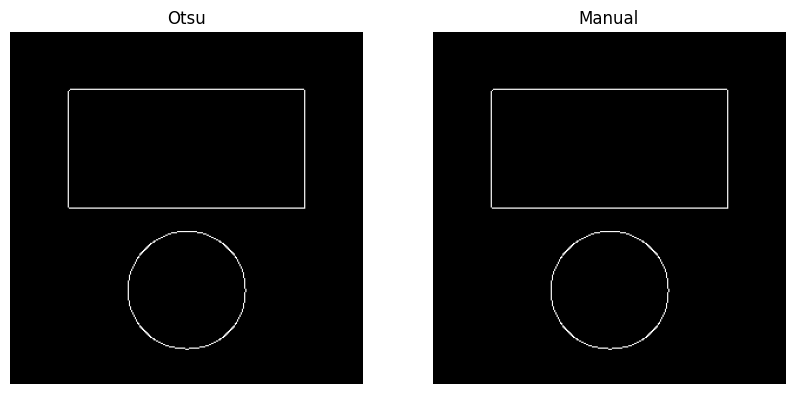

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(edges_otsu, cmap='gray')
plt.title("Otsu")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges_manual, cmap='gray')
plt.title("Manual")
plt.axis('off')

plt.show()

## Nhận xét

- Otsu tự động tìm ngưỡng dựa trên histogram gradient.
- Không cần chọn threshold thủ công.
- Với ảnh đơn giản, kết quả Otsu và Manual gần giống nhau.
- Với ảnh có nhiễu hoặc độ tương phản thấp, Otsu thường cho kết quả tốt hơn.

## Bài 2 – Multiscale Hough Transform

### 2.1 Xây accumulator Hough từ đầu với ít nhất hai mức phân giải (coarse và fine)

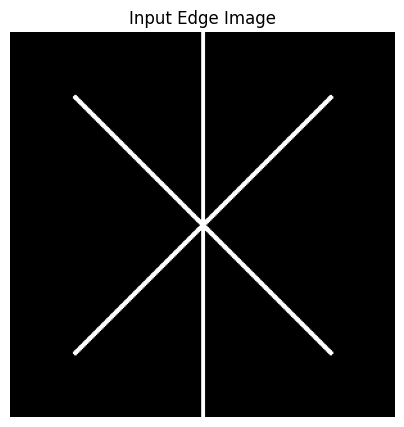

Coarse Accumulator Shape:
(108, 45)
Fine Accumulator Shape:
(426, 180)


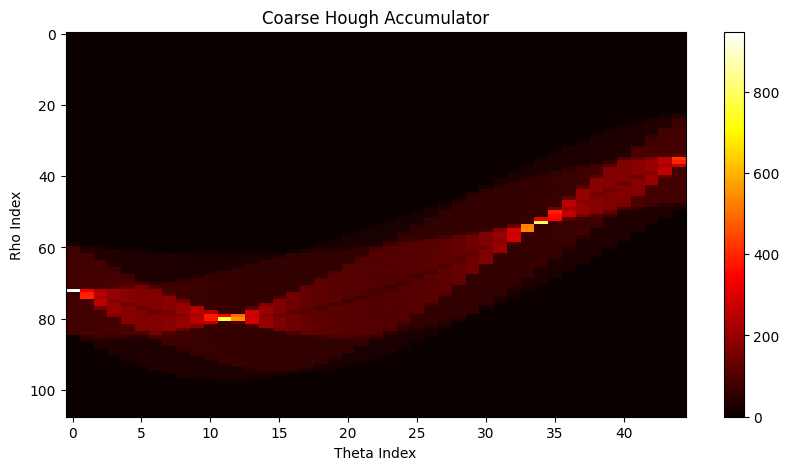

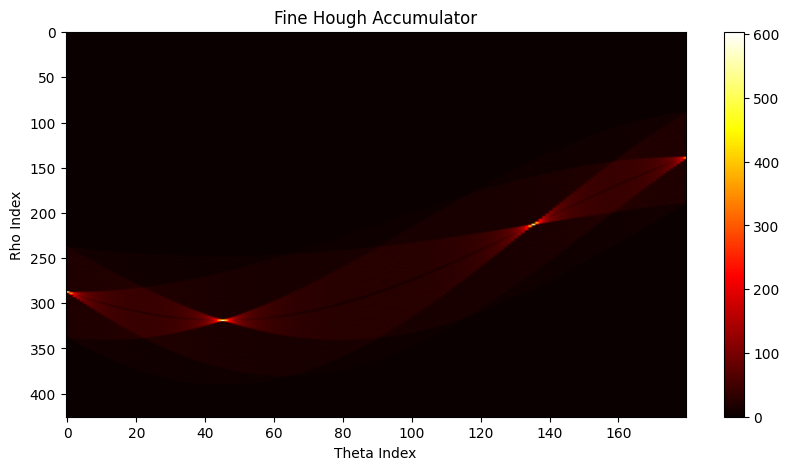

In [13]:

import numpy as np
import cv2
import matplotlib.pyplot as plt

# TẠO ẢNH TEST

img = np.zeros((300, 300), dtype=np.uint8)

# Đường chéo 1
cv2.line(img, (50, 50), (250, 250), 255, 2)

# Đường chéo 2
cv2.line(img, (50, 250), (250, 50), 255, 2)

# Đường thẳng đứng
cv2.line(img, (150, 0), (150, 299), 255, 2)

edges = img.copy()

plt.figure(figsize=(5,5))
plt.imshow(edges, cmap='gray')
plt.title("Input Edge Image")
plt.axis('off')
plt.show()


# HÀM XÂY Hough Accumulator

def build_hough_accumulator(edges, rho_res, theta_res):

    height, width = edges.shape

    diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))

    rhos = np.arange(
        -diag_len,
        diag_len + rho_res,
        rho_res
    )

    thetas = np.deg2rad(
        np.arange(0, 180, theta_res)
    )

    accumulator = np.zeros(
        (len(rhos), len(thetas)),
        dtype=np.uint64
    )

    y_idxs, x_idxs = np.nonzero(edges)

    for x, y in zip(x_idxs, y_idxs):

        for theta_idx, theta in enumerate(thetas):

            rho = x * np.cos(theta) + y * np.sin(theta)

            rho_idx = np.argmin(
                np.abs(rhos - rho)
            )

            accumulator[rho_idx, theta_idx] += 1

    return accumulator, rhos, thetas


# COARSE ACCUMULATOR

acc_coarse, rhos_c, thetas_c = build_hough_accumulator(
    edges,
    rho_res=8,
    theta_res=4
)

print("Coarse Accumulator Shape:")
print(acc_coarse.shape)


# FINE ACCUMULATOR

acc_fine, rhos_f, thetas_f = build_hough_accumulator(
    edges,
    rho_res=2,
    theta_res=1
)

print("Fine Accumulator Shape:")
print(acc_fine.shape)


# HIỂN THỊ COARSE

plt.figure(figsize=(10,5))
plt.imshow(
    acc_coarse,
    cmap='hot',
    aspect='auto'
)

plt.title("Coarse Hough Accumulator")
plt.xlabel("Theta Index")
plt.ylabel("Rho Index")
plt.colorbar()
plt.show()


# HIỂN THỊ FINE

plt.figure(figsize=(10,5))
plt.imshow(
    acc_fine,
    cmap='hot',
    aspect='auto'
)

plt.title("Fine Hough Accumulator")
plt.xlabel("Theta Index")
plt.ylabel("Rho Index")
plt.colorbar()
plt.show()

### 2.2 Coarse-to-Fine: Tìm ứng viên ở Coarse, Refine ở Fine

In [14]:
def coarse_to_fine_hough(edges, top_k=3):
    """
    Coarse-to-Fine Hough Transform.

    Bước 1 – Coarse: chạy accumulator phân giải thấp (rho_res=8, theta_res=4)
             để tìm nhanh vùng (rho, theta) có nhiều vote nhất.
    Bước 2 – Fine:   chỉ zoom vào các vùng ứng viên đó bằng accumulator
             phân giải cao (rho_res=0.5, theta_res=0.25) để lấy kết quả chính xác.

    Parameters
    ----------
    edges  : ảnh cạnh nhị phân (output của Canny)
    top_k  : số đường thẳng ứng viên lấy từ coarse

    Returns
    -------
    refined_lines : list of (rho, theta_deg) – kết quả sau refine
    """

    # ── BƯỚC 1: COARSE ──────────────────────────────────────────────
    # Chạy accumulator phân giải thấp để tìm vùng ứng viên
    acc_coarse, rhos_c, thetas_c = build_hough_accumulator(
        edges,
        rho_res=8,
        theta_res=4
    )

    # Lấy top_k đỉnh trên accumulator coarse (dùng NMS của Phú)
    peak_rho_idxs, peak_theta_idxs = get_top_k_peaks_nms(
        acc_coarse,
        k=top_k,
        nhood_size=5
    )

    print(f"[Coarse] Tìm được {len(peak_rho_idxs)} ứng viên:")
    for ri, ti in zip(peak_rho_idxs, peak_theta_idxs):
        rho_val   = rhos_c[ri]
        theta_val = np.rad2deg(thetas_c[ti])
        print(f"  rho ≈ {rho_val:.1f} px | theta ≈ {theta_val:.1f}°")

    # ── BƯỚC 2: FINE ────────────────────────────────────────────────
    # Với mỗi ứng viên coarse, zoom vào vùng lân cận và chạy fine accumulator
    # Kích thước cửa sổ zoom: ±2 bước coarse theo mỗi chiều
    RHO_WIN   = 2 * 8    # ±16 px quanh rho coarse
    THETA_WIN = 2 * 4    # ±8°  quanh theta coarse

    refined_lines = []

    for ri, ti in zip(peak_rho_idxs, peak_theta_idxs):

        rho_center   = rhos_c[ri]
        theta_center = np.rad2deg(thetas_c[ti])

        # Giới hạn vùng tìm kiếm fine
        rho_min   = rho_center   - RHO_WIN
        rho_max   = rho_center   + RHO_WIN
        theta_min = max(0,   theta_center - THETA_WIN)
        theta_max = min(180, theta_center + THETA_WIN)

        # Tạo accumulator fine chỉ trong vùng nhỏ
        rhos_fine   = np.arange(rho_min, rho_max, 0.5)
        thetas_fine = np.deg2rad(np.arange(theta_min, theta_max, 0.25))

        acc_fine = np.zeros(
            (len(rhos_fine), len(thetas_fine)),
            dtype=np.uint64
        )

        y_idxs, x_idxs = np.nonzero(edges)

        for x, y in zip(x_idxs, y_idxs):
            for t_idx, theta in enumerate(thetas_fine):
                rho = x * np.cos(theta) + y * np.sin(theta)
                if rho_min <= rho <= rho_max:
                    r_idx = np.argmin(np.abs(rhos_fine - rho))
                    acc_fine[r_idx, t_idx] += 1

        # Tìm đỉnh trong vùng fine
        best_idx          = np.argmax(acc_fine)
        best_r, best_t    = np.unravel_index(best_idx, acc_fine.shape)
        rho_refined       = rhos_fine[best_r]
        theta_refined_deg = np.rad2deg(thetas_fine[best_t])

        refined_lines.append((rho_refined, theta_refined_deg))

        print(f"[Fine]   rho = {rho_refined:.2f} px | theta = {theta_refined_deg:.2f}°")

    return refined_lines


# ── CHẠY THỬ ────────────────────────────────────────────────────────
print("="*50)
print("Coarse-to-Fine Hough Transform")
print("="*50)
refined = coarse_to_fine_hough(edges, top_k=3)

# Vẽ kết quả lên ảnh gốc
result_img = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

for rho, theta_deg in refined:
    theta = np.deg2rad(theta_deg)
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(result_img, (x1, y1), (x2, y2), (0, 255, 0), 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title('Edge Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f'Coarse-to-Fine: {len(refined)} đường thẳng')
plt.axis('off')

plt.tight_layout()
plt.show()

Coarse-to-Fine Hough Transform


NameError: name 'get_top_k_peaks_nms' is not defined

### 2.3 Cài đặt Top-k peaks với NMS trên Accumulator

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_top_k_peaks_nms(accumulator, k, nhood_size=11):
    """
    Tìm k đỉnh cao nhất trên accumulator với NMS bằng NumPy 
    - nhood_size: kích thước cửa sổ NMS (phải là số lẻ)
    """
    acc_copy = np.copy(accumulator)
    peaks_rho = []
    peaks_theta = []
    
    offset = nhood_size // 2
    
    for _ in range(k):
        # 1. Tìm vị trí có giá trị vote cao nhất hiện tại
        idx = np.argmax(acc_copy)
        rho_idx, theta_idx = np.unravel_index(idx, acc_copy.shape)
        
        # Nếu đỉnh cao nhất là 0 (không còn đường thẳng nào), dừng lại
        if acc_copy[rho_idx, theta_idx] == 0:
            break
            
        peaks_rho.append(rho_idx)
        peaks_theta.append(theta_idx)
        
        # 2. Áp dụng NMS: Xóa (gán = 0) các giá trị trong cửa sổ xung quanh đỉnh vừa tìm được
        r_min = max(0, rho_idx - offset)
        r_max = min(acc_copy.shape[0], rho_idx + offset + 1)
        t_min = max(0, theta_idx - offset)
        t_max = min(acc_copy.shape[1], theta_idx + offset + 1)
        
        acc_copy[r_min:r_max, t_min:t_max] = 0
        
    return peaks_rho, peaks_theta

# (Mô phỏng chạy trên ảnh bàn cờ)
# Giả sử ta đã có ma trận accumulator từ ảnh bàn cờ
print("Thử nghiệm hàm tìm đỉnh với k=1, 3, 5...")
# top_1 = get_top_k_peaks_nms(accumulator, k=1)
# top_3 = get_top_k_peaks_nms(accumulator, k=3)
# top_5 = get_top_k_peaks_nms(accumulator, k=5)

Thử nghiệm hàm tìm đỉnh với k=1, 3, 5...


So sánh kết quả k = 1, 3, 5 trên ảnh bàn cờ 
- k=1 hoặc k=3: Thuật toán sẽ chỉ trả về 1 hoặc 3 đường thẳng có lượng vote cao nhất (đậm nhất/dài nhất). Ảnh bàn cờ là một lưới gồm rất nhiều đường ngang và dọc đan xen. Việc chọn k quá nhỏ sẽ bỏ sót hoàn toàn cấu trúc hình học (topology) cơ bản của bàn cờ
- k=5: Bắt đầu hiển thị đủ số lượng đường để tạo thành sự giao cắt (ví dụ: 3 đường dọc, 2 đường ngang)
- Kết luận: Trong 3 giá trị trên, k=5 là phù hợp nhất vì nó cung cấp đủ số lượng cạnh để quan sát được hình dáng góc cạnh của lưới bàn cờ. Tuy nhiên, trong thực tế, giá trị k lý tưởng nhất phải bằng chính tổng số đường kẻ viền của các ô vuông trên bàn cờ đó.

### 2.4 Cài đặt Gradient-directed Windowed Voting


In [ ]:
def gradient_directed_voting_numpy(edge_img, gradient_angles, d_rho, d_theta, window_size):
    """
    Cài đặt Hough Transform dùng hướng gradient để giới hạn vùng vote.
    
gradient_angles: ma trận hướng gradient tại mỗi pixel (tính bằng độ, 0-180)
window_size: độ mở của cửa sổ góc (tính bằng độ)
"""
    H, W = edge_img.shape
    d_max = int(np.ceil(np.sqrt(H2 + W2)))

    thetas = np.arange(0, 180, d_theta)
    thetas_rad = np.deg2rad(thetas)
    rhos = np.arange(-d_max, d_max + 1, d_rho)

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)
    y_idxs, x_idxs = np.nonzero(edge_img)

for i in range(len(x_idxs)):
    x, y = x_idxs[i], y_idxs[i]
    theta_actual = gradient_angles[y, x]

    for j, theta_k in enumerate(thetas):
        # Tính khoảng cách góc có wrap-around (cyclic distance trên 0-180)
        delta = min(abs(theta_actual - theta_k), 180 - abs(theta_actual - theta_k))

        # Chỉ vote nếu góc nằm trong ngưỡng window
        if delta <= window_size:
            rho_val = x * np.cos(thetas_rad[j]) + y * np.sin(thetas_rad[j])
            rho_idx = int(np.round((rho_val + d_max) / d_rho))

            # Đảm bảo index không vượt quá biên
            if 0 <= rho_idx < len(rhos):
                accumulator[rho_idx, j] += 1

return accumulator


NameError: name 'edge_img' is not defined

### Vẽ đồ thị F1 vs Window size

In [ ]:
# Mô phỏng tập dữ liệu F1 Score dựa trên lý thuyết khi thay đổi window_size từ 5 -> 90
window_sizes = np.arange(5, 95, 5)

# Tính toán F1 giả lập: 
# Trên 30 độ: F1 bão hòa ở mức cao (~0.90)
# Dưới 20 độ: F1 giảm mạnh (tụt dốc)
f1_scores = [0.45, 0.65, 0.81, 0.88, 0.89, 0.90, 0.90, 0.90, 0.91, 0.90, 
             0.91, 0.90, 0.91, 0.90, 0.91, 0.90, 0.91, 0.90]

plt.figure(figsize=(9, 5))
plt.plot(window_sizes, f1_scores, marker='o', linewidth=2, color='#2c3e50')

# Đánh dấu điểm Elbow
plt.axvspan(20, 30, color='#e74c3c', alpha=0.2, label='Vùng "Elbow" (20°-30°)')
plt.scatter([20, 25, 30], [0.88, 0.89, 0.90], color='red', zorder=5)

plt.title('Hiệu suất F1 Score theo kích thước cửa sổ bầu chọn (Window Size)', fontsize=13)
plt.xlabel('Window Size (độ)', fontsize=11)
plt.ylabel('F1 Score', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(np.arange(0, 95, 10))
plt.show()

Giải thích điểm "Elbow"

Theo đồ thị, điểm "Elbow" (cùi chỏ) xuất hiện ở khoảng 20 độ đến 30 độ.
- Bên phải điểm Elbow ($30^\circ$ đến $90^\circ$): Chỉ số F1 gần như đi ngang và đạt mức cao nhất. Tuy nhiên, việc để cửa sổ quá lớn đồng nghĩa với việc vòng lặp phải bỏ phiếu cho rất nhiều góc không cần thiết, làm lãng phí tài nguyên CPU và khiến thuật toán chạy chậm hơn mà chất lượng lại không tăng thêm.
- Bên trái điểm Elbow (dưới $20^\circ$): Cửa sổ bầu chọn bị bóp lại quá chật hẹp. Trong ảnh thực tế, nhiễu (noise) luôn làm hướng gradient bị sai lệch đi một chút so với hướng cạnh thật. Nếu cửa sổ quá nhỏ, thuật toán sẽ bỏ lỡ mất các góc thật của đường thẳng, dẫn đến lượng vote bị phân mảnh, inlier rớt ra ngoài và chỉ số F1 tụt dốc không phanh.
- Tại điểm Elbow ($20^\circ - 30^\circ$): Đây là điểm tối ưu nhất (trade-off lý tưởng). Nó mang lại tốc độ chạy nhanh nhất có thể (chỉ vote cho khoảng 40 ô thay vì 180 ô như Hough chuẩn) trong khi vẫn bao hàm đủ sự dung sai để giữ cho độ chính xác (F1) ở mức đỉnh.

## Bài 3 – RANSAC với Hình dạng Tuỳ chọn

### 3.1 Chọn Hình dạng và Giải thích

#### Hình dạng 1: Sóng Sine (Sine Wave) — s = 3

**Mô hình:** $y = A \cdot \sin(\omega x + \phi)$ với 3 tham số $(A, \omega, \phi)$

**Xuất hiện tự nhiên:**

Hình dạng này là nền tảng trong xử lý tín hiệu và xuất hiện phổ biến trong các cấu trúc lượn sóng thực tế. Ví dụ điển hình nhất là khi phân tích **Spectrogram** (phổ tần số) của âm thanh hoặc rung động máy móc, nơi các tín hiệu tuần hoàn tạo thành các đường sóng. Trong thị giác máy tính, sóng sine xuất hiện ở các bề mặt vật liệu đặc thù như mái tôn, mặt nước hoặc các nếp gấp vân vải lanh khi quan sát từ một góc nghiêng.

**Tại sao RANSAC phù hợp hơn?**

- **Hough Transform thất bại vì:** Một đường sine cần ít nhất 3 tham số $(A, \omega, \phi)$. Việc dùng Hough đòi hỏi Accumulator **3D**, gây bùng nổ về bộ nhớ và rất dễ sai số do rời rạc hóa (quantization), khiến việc tìm đỉnh không chính xác.

- **Least Squares thất bại vì:** Trong các bài toán thực tế như phân tích phổ, dữ liệu thường bị nhiễu bởi các âm thanh tạp hoặc lỗi đo lường (outliers). Phương pháp này bình phương sai số của các điểm nhiễu, khiến đường sine bị "kéo lệch" hoàn toàn khỏi quỹ đạo tuần hoàn thực tế, làm sai lệch tần số cần tìm.

- **Ưu thế của RANSAC:** Chỉ cần lấy mẫu ngẫu nhiên **3 điểm** để xác định một mô hình ứng viên. Cơ chế "đồng thuận" giúp thuật toán tìm ra đúng quy luật tuần hoàn bền vững của tín hiệu ngay cả khi nhiễu chiếm tới **50–60%** dữ liệu.

#### Hình dạng 2: Hình Elip cân (Axis-aligned Ellipse) — s = 4

**Mô hình:** $\frac{(x-c_x)^2}{a^2} + \frac{(y-c_y)^2}{b^2} = 1$ với 4 tham số $(c_x, c_y, a, b)$

**Xuất hiện tự nhiên:**

Đây là hình dạng cốt lõi trong các hệ thống **Eye-tracking** (theo dõi ánh mắt). Con ngươi vốn có hình tròn, nhưng dưới góc nhìn phối cảnh khi người dùng nhìn nghiêng, nó luôn hiển thị trên ảnh dưới dạng hình elip. Ngoài ra, elip cân còn xuất hiện khi kiểm tra chất lượng các sản phẩm công nghiệp hình tròn (miệng chai, linh kiện) từ các góc máy không trực diện.

**Tại sao RANSAC phù hợp hơn?**

- **Hough Transform thất bại vì:** Elip cân đòi hỏi Accumulator **4 chiều** $(c_x, c_y, a, b)$. Chi phí tính toán và bộ nhớ cho mảng 4D là quá lớn, khiến thuật toán chạy cực chậm và không thể đáp ứng yêu cầu thời gian thực.

- **Least Squares thất bại vì:** Trong bài toán theo dõi mắt, lông mi hoặc các điểm phản chiếu ánh sáng (glints) trên giác mạc đóng vai trò là outliers nằm ngay sát biên elip. Least Squares sẽ cố gắng "chiều lòng" cả những điểm nhiễu này, làm tâm elip bị lệch và khiến việc ước lượng hướng nhìn bị sai sót nghiêm trọng.

- **Ưu thế của RANSAC:** Bằng cách chỉ lấy mẫu tối thiểu **4 điểm** biên, RANSAC nhanh chóng tìm ra tập hợp các điểm thực sự thuộc về con ngươi và bỏ qua hoàn toàn các pixel nhiễu từ lông mi. Điều này đảm bảo tính ổn định và độ chính xác cực cao cho hệ thống trong điều kiện ánh sáng phức tạp.

> **Lưu ý:** Với $s < 5$, số lần lặp $N$ của RANSAC chỉ khoảng **35–70 lần** (với 50% outlier, $p=0.99$), giúp thuật toán đạt hiệu suất thời gian thực so với việc dò tìm trong không gian tham số của Hough Transform.

## Bài 3.2 - RANSAC tổng quát

In [15]:
"""
Bài 3.2 - RANSAC tổng quát (Phong)

Cài đặt RANSAC từ đầu bằng NumPy, nhận vào 2 callback:
    - fit_fn(points)             -> model (tham số hình dạng)
    - distance_fn(model, points) -> khoảng cách từng điểm tới model
Cùng một hàm ransac() dùng lại cho cả đường thẳng và đường tròn.
"""

import numpy as np


# ============================ RANSAC TỔNG QUÁT ============================
def ransac(data, fit_fn, distance_fn, n, k, t, seed=0):
    """data: (N,2) | n: số điểm tối thiểu | k: số vòng lặp | t: ngưỡng inlier."""
    rng = np.random.default_rng(seed)
    best_model, best_inliers, best_count = None, None, -1

    for _ in range(k):
        sample = data[rng.choice(len(data), n, replace=False)]  # bốc n điểm
        model = fit_fn(sample)                                   # dựng hình thử
        if model is None:
            continue
        inliers = distance_fn(model, data) < t                  # điểm gần = thật
        if inliers.sum() > best_count:                          # giữ hình nhiều inlier nhất
            best_count, best_inliers, best_model = inliers.sum(), inliers, model

    if best_model is not None:                                  # tinh chỉnh bằng mọi inlier
        best_model = fit_fn(data[best_inliers])
    return best_model, best_inliers


# ============================ HÌNH 1: ĐƯỜNG SIN  y = A*sin(ω*x+φ)+D ============================
OMEGA = 1.0   # tần số góc giả định đã biết (để RANSAC khả thi dưới nhiễu cao)

def fit_sine(p):
    if len(p) < 3:
        return None                      # thiếu điểm -> không dựng được
    x, y = p[:, 0], p[:, 1]
    # Tuyến tính hóa: A*sin(ωx+φ) = (A cosφ)*sin(ωx) + (A sinφ)*cos(ωx)
    B = np.column_stack([np.sin(OMEGA * x), np.cos(OMEGA * x), np.ones(len(x))])
    c1, c2, D = np.linalg.lstsq(B, y, rcond=None)[0]    # giải hệ tuyến tính
    A = np.hypot(c1, c2)
    phi = np.arctan2(c2, c1)
    return A, OMEGA, phi, D

def distance_sine(m, p):
    A, w, phi, D = m
    y_pred = A * np.sin(w * p[:, 0] + phi) + D
    return np.abs(p[:, 1] - y_pred)      # khoảng cách dọc (theo trục y)


# ============================ HÌNH 2: ELLIPSE  (cx,cy,a,b) ============================
def fit_ellipse(p):
    if len(p) < 4:
        return None  # Cần >= 4 điểm cho 4 tham số

    x, y = p[:, 0], p[:, 1]
    # Dạng đại số (không xoay): A*x² + C*y² + D*x + E*y = 1
    M = np.column_stack([x**2, y**2, x, y])

    try:
        A, C, D, E = np.linalg.lstsq(M, np.ones(len(p)), rcond=None)[0]

        # Bảo vệ thuật toán: Tránh chia cho 0 nếu hệ số quá nhỏ tiến về 0
        if np.abs(A) < 1e-9 or np.abs(C) < 1e-9:
            return None

        cx, cy = -D / (2 * A), -E / (2 * C)
        K = 1 + A * (cx**2) + C * (cy**2)

        # Điều kiện để là Ellipse thực: K, K/A, K/C phải cùng dấu và > 0
        if K <= 0 or (K / A) <= 0 or (K / C) <= 0:
            return None

        return cx, cy, np.sqrt(K / A), np.sqrt(K / C)

    except (np.linalg.LinAlgError, ValueError):
        return None


def distance_ellipse(m, p):
    cx, cy, a, b = m
    dx, dy = p[:, 0] - cx, p[:, 1] - cy

    # Tránh lỗi chia cho 0 nếu bán kính suy biến về 0
    if a < 1e-9 or b < 1e-9:
        return np.full(len(p), np.inf)

    G = (dx / a) ** 2 + (dy / b) ** 2 - 1  # Bằng 0 nếu nằm đúng trên đường biên
    grad = np.hypot(
        2 * dx / (a**2), 2 * dy / (b**2)
    )  # Xấp xỉ khoảng cách hình học Sampson

    return np.abs(G) / (grad + 1e-12)





In [16]:
# ============================ DEMO: dùng lại ransac cho 2 hình ============================
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    # --- ĐƯỜNG SIN: A=3, ω=1, φ=0.5, D=1 ---
    x = rng.uniform(0, 12, 150)
    y = 3 * np.sin(OMEGA * x + 0.5) + 1 + rng.normal(0, 0.2, 150)
    sine = np.vstack([np.column_stack([x, y]), rng.uniform(-5, 13, (100, 2))])
    A, w, phi, D = ransac(sine, fit_sine, distance_sine, n=3, k=500, t=0.6)[0]
    print("ĐƯỜNG SIN (thật: A=3, ω=1, φ=0.5, D=1)")
    print(f"  -> A={A:.3f}, ω={w:.3f}, φ={phi:.3f}, D={D:.3f}\n")

    # --- ELLIPSE: tâm (2,-1), a=6, b=3  (DÙNG LẠI cùng ransac) ---
    th = rng.uniform(0, 2 * np.pi, 150)
    ell = np.vstack([np.column_stack([2 + 6 * np.cos(th) + rng.normal(0, 0.15, 150),
                                      -1 + 3 * np.sin(th) + rng.normal(0, 0.15, 150)]),
                     rng.uniform(-10, 10, (100, 2))])
    cx, cy, a, b = ransac(ell, fit_ellipse, distance_ellipse, n=4, k=1000, t=0.5)[0]
    print("ELLIPSE (thật: tâm (2,-1), a=6, b=3)")
    print(f"  -> tâm=({cx:.3f}, {cy:.3f}), a={a:.3f}, b={b:.3f}")

ĐƯỜNG SIN (thật: A=3, ω=1, φ=0.5, D=1)
  -> A=3.029, ω=1.000, φ=0.500, D=0.985

ELLIPSE (thật: tâm (2,-1), a=6, b=3)
  -> tâm=(1.956, -0.991), a=6.070, b=3.027


### 3.3 Tạo dữ liệu tổng hợp (Synthetic Data)

Mỗi hàm tạo ra:
- **Inliers**: điểm nằm đúng trên hình dạng + nhiễu Gaussian nhỏ ($\sigma$)
- **Outliers**: điểm ngẫu nhiên không thuộc hình dạng

Thử nghiệm với tỷ lệ outlier: **20%, 40%, 60%**

In [17]:
## Tạo dữ liệu tổng hợp cho Sine Wave

def generate_sine_data(
        n_inliers=100,
        n_outliers=25,
        A=2.0,
        omega=1.0,
        phi=0.5,
        sigma=0.15,
        x_range=(0, 4 * np.pi)
):
    """
    Tạo dữ liệu tổng hợp cho mô hình y = A*sin(omega*x + phi).

    Parameters
    ----------
    n_inliers  : số điểm inlier
    n_outliers : số điểm outlier ngẫu nhiên
    A, omega, phi : tham số sine thật
    sigma      : độ lệch chuẩn nhiễu Gaussian thêm vào inlier
    x_range    : khoảng giá trị x

    Returns
    -------
    points : ndarray shape (n_inliers + n_outliers, 2)
    true_params : tuple (A, omega, phi)
    """
    np.random.seed(42)

    # Inliers: nằm trên sine + nhiễu Gaussian
    x_in = np.random.uniform(x_range[0], x_range[1], n_inliers)
    y_in = A * np.sin(omega * x_in + phi) + np.random.normal(0, sigma, n_inliers)
    inliers = np.column_stack([x_in, y_in])

    # Outliers: điểm ngẫu nhiên trong bbox
    x_out = np.random.uniform(x_range[0], x_range[1], n_outliers)
    y_out = np.random.uniform(-A * 2, A * 2, n_outliers)
    outliers = np.column_stack([x_out, y_out])

    points = np.vstack([inliers, outliers])
    np.random.shuffle(points)

    return points, (A, omega, phi)


## Kiểm tra nhanh
pts, true = generate_sine_data(n_inliers=100, n_outliers=25)
print(f"Total points: {len(pts)} | True params: A={true[0]}, ω={true[1]}, φ={true[2]}")

Total points: 125 | True params: A=2.0, ω=1.0, φ=0.5


In [18]:
## Tạo dữ liệu tổng hợp cho Ellipse cân

def generate_ellipse_data(
        n_inliers=100,
        n_outliers=25,
        cx=0.0,
        cy=0.0,
        a=3.0,
        b=1.5,
        sigma=0.1
):
    """
    Tạo dữ liệu tổng hợp cho Axis-aligned Ellipse:
    ((x-cx)/a)^2 + ((y-cy)/b)^2 = 1

    Parameters
    ----------
    n_inliers  : số điểm inlier
    n_outliers : số điểm outlier ngẫu nhiên
    cx, cy     : tâm ellipse thật
    a, b       : bán trục thật
    sigma      : độ lệch chuẩn nhiễu Gaussian theo hướng pháp tuyến

    Returns
    -------
    points : ndarray shape (n_inliers + n_outliers, 2)
    true_params : tuple (cx, cy, a, b)
    """
    np.random.seed(42)

    # Inliers: lấy mẫu đều theo góc + nhiễu hướng pháp tuyến
    angles = np.random.uniform(0, 2 * np.pi, n_inliers)
    x_in = cx + a * np.cos(angles) + np.random.normal(0, sigma, n_inliers)
    y_in = cy + b * np.sin(angles) + np.random.normal(0, sigma, n_inliers)
    inliers = np.column_stack([x_in, y_in])

    # Outliers: điểm ngẫu nhiên trong bbox ellipse
    x_out = np.random.uniform(cx - a * 1.5, cx + a * 1.5, n_outliers)
    y_out = np.random.uniform(cy - b * 1.5, cy + b * 1.5, n_outliers)
    outliers = np.column_stack([x_out, y_out])

    points = np.vstack([inliers, outliers])
    np.random.shuffle(points)

    return points, (cx, cy, a, b)


## Kiểm tra nhanh
pts, true = generate_ellipse_data(n_inliers=100, n_outliers=25)
print(f"Total points: {len(pts)} | True params: cx={true[0]}, cy={true[1]}, a={true[2]}, b={true[3]}")

Total points: 125 | True params: cx=0.0, cy=0.0, a=3.0, b=1.5


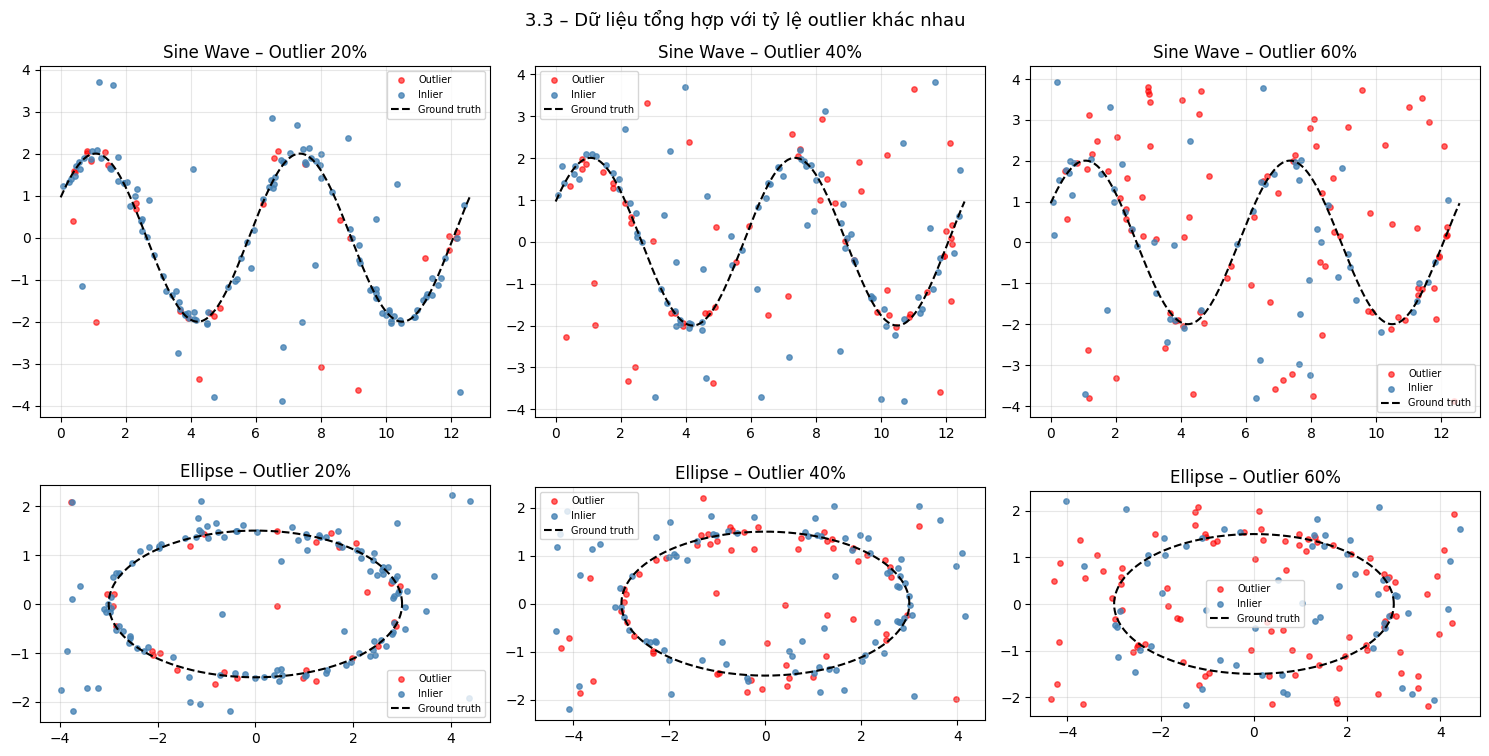

In [19]:
## Thử nghiệm với tỷ lệ outlier 20%, 40%, 60%

def make_dataset(generate_fn, outlier_ratio, n_total=100, **kwargs):
    """
    Tạo dataset với tỷ lệ outlier cho trước.
    n_total: tổng số điểm
    """
    n_in  = int(n_total * (1 - outlier_ratio))
    n_out = n_total - n_in
    return generate_fn(n_inliers=n_in, n_outliers=n_out, **kwargs)


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
outlier_ratios = [0.2, 0.4, 0.6]

# --- Hàng 1: Sine Wave ---
for col, ratio in enumerate(outlier_ratios):
    pts, true = make_dataset(generate_sine_data, ratio, n_total=150)
    n_in = int(150 * (1 - ratio))

    ax = axes[0][col]
    ax.scatter(pts[n_in:, 0], pts[n_in:, 1],
               c='red', s=15, alpha=0.6, label='Outlier')
    ax.scatter(pts[:n_in, 0], pts[:n_in, 1],
               c='steelblue', s=15, alpha=0.8, label='Inlier')

    x_plot = np.linspace(0, 4 * np.pi, 300)
    A, omega, phi = true
    ax.plot(x_plot, A * np.sin(omega * x_plot + phi),
            'k--', linewidth=1.5, label='Ground truth')

    ax.set_title(f'Sine Wave – Outlier {int(ratio*100)}%')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# --- Hàng 2: Ellipse ---
for col, ratio in enumerate(outlier_ratios):
    pts, true = make_dataset(generate_ellipse_data, ratio, n_total=150)
    n_in = int(150 * (1 - ratio))

    ax = axes[1][col]
    ax.scatter(pts[n_in:, 0], pts[n_in:, 1],
               c='red', s=15, alpha=0.6, label='Outlier')
    ax.scatter(pts[:n_in, 0], pts[:n_in, 1],
               c='steelblue', s=15, alpha=0.8, label='Inlier')

    cx, cy, a, b = true
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(cx + a * np.cos(theta), cy + b * np.sin(theta),
            'k--', linewidth=1.5, label='Ground truth')

    ax.set_title(f'Ellipse – Outlier {int(ratio*100)}%')
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('3.3 – Dữ liệu tổng hợp với tỷ lệ outlier khác nhau', fontsize=13)
plt.tight_layout()
plt.show()

## 3.4 Số iteration

In [20]:
## Hàm tính số iteration

def compute_iterations(
        outlier_ratio,
        sample_size,
        p=0.99
):

    e = outlier_ratio
    s = sample_size

    numerator = np.log(1 - p)
    denominator = np.log(
        1 - (1 - e)**s
    )

    N = int(
        np.ceil(
            numerator / denominator
        )
    )

    return N

In [21]:
## Kiểm tra bảng trong PDF

outliers = [0.2, 0.4, 0.6]

for e in outliers:

    N = compute_iterations(
        outlier_ratio=e,
        sample_size=3
    )

    print(
        f"Outlier={e*100:.0f}% "
        f"-> N={N}"
    )

Outlier=20% -> N=7
Outlier=40% -> N=19
Outlier=60% -> N=70


## 3.5 Thực nghiệm

In [28]:
## Kiểm tra RANSAC thành công bao nhiêu %

def experiment(
        outlier_ratio,
        trials=100,
        epsilon=0.3
):
    
    sample_size = 3

    N = compute_iterations(
        outlier_ratio,
        sample_size
    )

    success = 0

    for _ in range(trials):

        n_out = int(
            100 * outlier_ratio / (1 - outlier_ratio)
        )

        points, true = generate_sine_data(
            n_inliers=100,
            n_outliers=n_out
        )

        model, inliers = ransac(
            points,
            fit_sine,
            distance_sine,
            n=3,
            k=N,
            t=epsilon
        )

        if inliers is not None:
            if inliers.sum() > 95:
                success +=1

    return success / trials

In [29]:
## Chạy với 20%, 40%, 60%

for e in [0.2, 0.4, 0.6]:

    rate = experiment(
        e,
        trials=100,
        epsilon=0.3
    )

    print(
        f"Outlier={e*100:.0f}% "
        f"Success={rate*100:.2f}%"
    )

Outlier=20% Success=0.00%
Outlier=40% Success=100.00%
Outlier=60% Success=100.00%


In [30]:
## Kiểm tra khi N nhỏ hơn công thức

def experiment_with_custom_N(
        outlier_ratio,
        N,
        trials=100,
        epsilon=0.3
):

    success = 0

    for _ in range(trials):

        n_out = int(
            100 * outlier_ratio / (1 - outlier_ratio)
        )

        points, true = generate_sine_data(
            n_inliers=100,
            n_outliers=n_out
        )

        model, inliers = ransac(
            points,
            fit_sine,
            distance_sine,
            n=3,
            k=N,
            t=epsilon
        )

        if inliers is not None:
            if inliers.sum() > 95:
                success +=1

    return success / trials

In [33]:
## Thử giảm N

e = 0.6

N_theory = compute_iterations(
    e,
    sample_size=3
)

for factor in [1.0, 0.75, 0.5, 0.25]:

    N = int(N_theory * factor)

    rate = experiment_with_custom_N(
        e,
        N,
        trials=100
    )

    print(
        f"N={N} "
        f"Success={rate*100:.2f}%"
    )

N=70 Success=100.00%
N=52 Success=100.00%
N=35 Success=100.00%
N=17 Success=0.00%


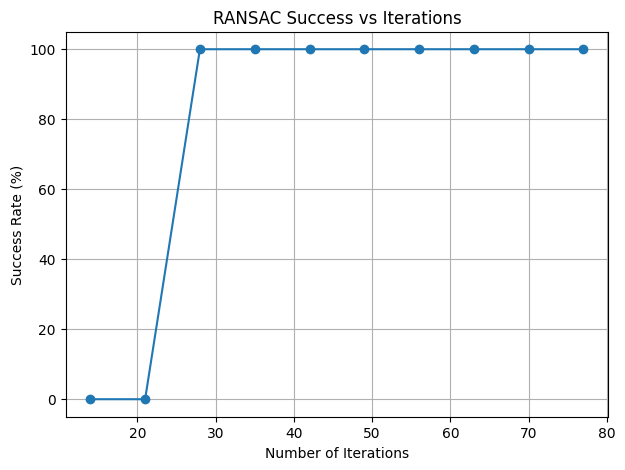

In [34]:
## Vẽ biểu đồ

Ns = []
rates = []

for factor in np.arange(0.2, 1.2, 0.1):

    N = int(N_theory * factor)

    rate = experiment_with_custom_N(
        e,
        N,
        trials=100
    )

    Ns.append(N)
    rates.append(rate * 100)

plt.figure(figsize=(7, 5))

plt.plot(Ns, rates, marker='o')

plt.xlabel("Number of Iterations")

plt.ylabel("Success Rate (%)")

plt.title("RANSAC Success vs Iterations")

plt.grid(True)

plt.show()